# Homework 3: WGAN and NCSN

## Task 1: Theory (5 pts)

### Problem 1: Conjugate functions / f-GAN (1 pt)
 
There is [paper](https://arxiv.org/pdf/1606.00709) that shows how to approximate any f-divergence using adversarial loss. 
We highly advice to read it, the math is cool. 
Here we will use this framework without proof:
$$
    D_f(\pi || p) \geq \sup_{T \in \mathcal{T}} \left[\mathbb{E}_{\pi}T(\mathbf{x}) -  \mathbb{E}_p f^*(T(\mathbf{x})) \right].
$$
The idea is the following: there is a lower bound on f-divergence which are given by variational inequality. So we could minimize this bound instead of initial f-divergence.

Here
$$
	f^*(t) = \sup_{u \in \text{dom}_f} \left( ut - f(u) \right)
$$
is a Fenchel conjugate function.

In this task you have to derive standard GAN objective from the variational inequality.

Let define function $f(u) = u \log u - (u + 1) \log (u + 1)$.

- Find $\text{dom}(f)$.
- Show that $f^*(t) = - \log (1 - e^t)$.
- Use reparametrization $T(\mathbf{x}) = \log D(\mathbf{x})$ to get the standard GAN objective (note that $D(\mathbf{x}) \in (0, 1)$, explain why this reparametrization is correct).


### Solution

1.
$\mathrm{dom}(\log(x)) = (0, \infty), \quad \mathrm{dom}(\log(x + 1)) = (-1, \infty) \implies \mathrm{dom}(f) = (0, \infty)$

2.
$f^*(t) = \sup_{u \in \mathrm{dom}{f}}(ut - u\log u + (u + 1)\log(u + 1))$

This function is concave. The hessian:

In [ ]:
import sympy as sp
t = sp.symbols("t", real=True, negative=True) # we will get this from the log D(x)
u = sp.symbols("u", real=True, positive=True)
f = u * t - u * sp.log(u) + (u + 1) * sp.log(u + 1)
gradient = sp.diff(f, u)
hessian = sp.diff(gradient, u)
hessian

1/(u + 1) - 1/u

Is negative $\forall u \in \mathrm{dom}(f)$

Hence we can find supremum by taking derivative and equating it to zero:

In [21]:
sp.solve(gradient, u)

[1/(-1 + exp(-t))]

The solution is $u = \frac{1}{e^{-t} - 1} = \frac{e^t}{1 - e^t}$.

Substituting this to the expression: 

In [28]:
expr = f.subs(u, sp.exp(t) / (1 - sp.exp(t))).simplify()
expr

-t + log(-1/(1 - exp(-t)))

which expands to:
$$
-t + \log \left( -\frac{1}{1 - e^{-t}} \right) = \log e^{-t} + \log \left( -\frac{e^t}{e^t - 1} \right) = \log \left( \frac{1}{1 - e^t} \right) = -\log (1 - e^t)
$$

3.

For obtained $f^*(t)$ we can substitute $t = \log D(\mathbf{x})$. Since $D(\mathbf{x}) \in (0, 1)$, we have $t \in (-\infty, 0)$.

Hence, we have the objective:
$$
\mathbb{E}_{\pi} \left[ \log D(\mathbf{x}) \right] + \mathbb{E}_p \left[ \log (1 - D(\mathbf{x})) \right]
$$

### Problem 2: Frechet Inception Distance (2 pts)
Let prove the theorem from the lecture.
Remember the Wasserstein metric:
$$
    W_s(\pi, p) = \inf_{\gamma \in \Gamma(\pi, p)} \left(\mathbb{E}_{(\mathbf{x}, \mathbf{y}) \sim \gamma} \| \mathbf{x} - \mathbf{y} \|^s\right)^{1/s}
$$

Consider the case $\mathbf{x} \sim \pi(\mathbf{x}) = \mathcal{N}(\boldsymbol{\mu}_1, \sigma_1^2 \mathbf{I})$, $\mathbf{y} \sim p(\mathbf{y}) = \mathcal{N}(\boldsymbol{\mu}_2, \sigma_2^2 \mathbf{I})$.

Let prove that in this case
$$
    W_2^2(\pi, p) = \inf_{\gamma \in \Gamma(\pi, p)} \mathbb{E}_{(\mathbf{x}, \mathbf{y}) \sim \gamma} \| \mathbf{x} - \mathbf{y} \|^2 = \| \boldsymbol{\mu}_1 - \boldsymbol{\mu}_2 \|^2 + m \cdot (\sigma_1 - \sigma_2)^2.
$$
Here $m$ is a dimensionality of the space ($\mathbf{x}, \mathbf{y} \in \mathbb{R}^m$).

**Hints:** (one of the possible solutions)
1. Consider the case $\boldsymbol{\mu}_1 = \boldsymbol{\mu}_2 = 0$.
2. Use Cauchy–Schwarz inequality to prove that the value given above is a minimal.
2. Find the analytical mapping between $\mathbf{x}$ and $\mathbf{y}$ that gives this value.

1.

For $\boldsymbol{\mu}_1 = \boldsymbol{\mu}_2 = 0$ we have:
$$
W_2^2(\pi, p) = m \cdot (\sigma_1 - \sigma_2)^2.
$$

2.

Let us prove that the value above is lower bound for any coupling $\gamma \in \Gamma(\pi, p)$.

$$
\mathbb{E} \| \mathbf{x} - \mathbf{y} \|^2 = \mathbb{E} \| \mathbf{x} \|^2 + \mathbb{E} \| \mathbf{y} \|^2 - 2 \mathbb{E} \langle \mathbf{x}, \mathbf{y} \rangle \overset{\text{Cauchy-Schwarz}}{\ge}  \mathbb{E} \| \mathbf{x} \|^2 + \mathbb{E} \| \mathbf{y} \|^2 - 2 \sqrt{\mathbb{E} \| \mathbf{x} \|^2 \mathbb{E} \| \mathbf{y} \|^2} = m \sigma_1^2 + m \sigma_2^2 - 2m \sigma_1 \sigma_2 = m (\sigma_1 - \sigma_2)^2
$$

This lower bound is achieved by coupling $\mathbf{y} = \frac{\sigma_2}{\sigma_1} \mathbf{x}$. Obviously, it preserves $\mathbf{x} \sim \mathcal{N}(\mathbf{0}, \sigma_1^2 \mathbf{I})$ and $\mathbf{y} \sim \mathcal{N}(\mathbf{0}, \sigma_2^2 \mathbf{I})$, and the value of the distance is 
$$
\mathbb{E} \| \mathbf{x} - \mathbf{y} \|^2 = \mathbb{E} \| \mathbf{x} - \frac{\sigma_2}{\sigma_1} \mathbf{x} \|^2 = \mathbb{E} \| (\sigma_1 - \sigma_2) \mathbf{z} \|^2 = (\sigma_1 - \sigma_2)^2 \mathbb{E} \| \mathbf{z} \|^2 = m (\sigma_1 - \sigma_2)^2
$$
where $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$.

3.

Let $\tilde{\mathbf{x}} \sim \mathcal{N}(\mathbf{0}, \boldsymbol{\sigma_1}^2 \mathbf{I})$, $\tilde{\mathbf{y}} \sim \mathcal{N}(\mathbf{0}, \boldsymbol{\sigma_2}^2 \mathbf{I}), \mathbf{x} = \boldsymbol{\mu}_1 + \tilde{\mathbf{x}}, \mathbf{y} = \boldsymbol{\mu}_2 + \tilde{\mathbf{y}}$. Then for any coupling $\gamma \in \Gamma(\pi, p)$ we have:
$$
\mathbf{x} - \mathbf{y} = \boldsymbol{\mu}_1 - \boldsymbol{\mu}_2 + \tilde{\mathbf{x}} - \tilde{\mathbf{y}}
$$
$$
\| \mathbf{x} - \mathbf{y} \|^2 = \| \boldsymbol{\mu}_1 - \boldsymbol{\mu}_2 \|^2 + \| \tilde{\mathbf{x}} - \tilde{\mathbf{y}} \|^2 + 2 \langle \boldsymbol{\mu}_1 - \boldsymbol{\mu}_2, \tilde{\mathbf{x}} - \tilde{\mathbf{y}} \rangle
$$
Taking expectation (and using the fact that $\mathbb{E} [\tilde{\mathbf{x}} - \tilde{\mathbf{y}}] = \mathbf{0}$) we get:
$$
\mathbb{E} \| \mathbf{x} - \mathbf{y} \|^2 = \| \boldsymbol{\mu}_1 - \boldsymbol{\mu}_2 \|^2 + \mathbb{E}\| \tilde{\mathbf{x}} - \tilde{\mathbf{y}} \|^2
$$
and we already know the minimizing coupling $\tilde{\mathbf{y}} = \frac{\sigma_2}{\sigma_1} \tilde{\mathbf{x}}$, giving the value:
$$
\mathbb{E} \| \mathbf{x} - \mathbf{y} \|^2 = \| \boldsymbol{\mu}_1 - \boldsymbol{\mu}_2 \|^2 + m (\sigma_1 - \sigma_2)^2
$$
which is achieved for coupling $\mathbf{y} = \boldsymbol{\mu}_2 + \frac{\sigma_2}{\sigma_1} (\mathbf{x} - \boldsymbol{\mu}_1)$.


### Problem 3: Implicit score matching (2 pts)

The objective of score matching is
$$
    \frac{1}{2} \mathbb{E}_{\pi}\bigl\| \mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x}) - \nabla_\mathbf{x} \log \pi(\mathbf{x}) \bigr\|^2_2 \rightarrow \min_{\boldsymbol{\theta}}.
$$

And we have already known one possible solution for this task. It is denoising score matching.

Here our goal is to derive one more way to solve the initial score matching problem. It is called **implicit score matching**.

Let consider 1-d case ($x \in \mathbb{R}$).
Prove that
$$
\frac{1}{2} \mathbb{E}_{\pi}\bigl\| s_{\boldsymbol{\theta}}(x) - \nabla_x \log \pi(x) \bigr\|^2_2 = \mathbb{E}_{\pi}\left[ \frac{1}{2}s^2_{\boldsymbol{\theta}}(x) + \nabla_{x} s_{\boldsymbol{\theta}}(x) \right] + \text{const}.
$$

- **Question:** Why is the expression at the right hand side better than the left one? 
  
  **Answer:** It is better because we do not have the term with the unknown distribution $\pi(x)$.

- **Question:** Why do we not use this expression instead of denoising score matching? 

  **Answer:** In this expression we have term $\nabla_{x} s_{\boldsymbol{\theta}}(x) = \nabla^2_{x} \log p(x | \boldsymbol{\theta})$. And it is difficult to work with the second derivates.

- **Question:** Why do we consider only 1-d case? 

  **Answer:** It is very straightforward to generalize this formula to the multidimensional case, but the derivation contains much more formulas.

### Solution

Let
$$
r(x) = \nabla_x \log \pi(x) = \frac{\pi'(x)}{\pi(x)}.
$$

Then
$$
\frac{1}{2} \mathbb{E}_{\pi}\bigl( s_{\boldsymbol{\theta}}(x) - r(x) \bigr)^2
=
\frac{1}{2} \mathbb{E}_{\pi} s_{\boldsymbol{\theta}}^2(x)
-
\mathbb{E}_{\pi}\bigl[s_{\boldsymbol{\theta}}(x) r(x)\bigr]
+
\frac{1}{2} \mathbb{E}_{\pi} r^2(x).
$$

Consider the middle term:
$$
\mathbb{E}_{\pi}\bigl[s_{\boldsymbol{\theta}}(x) r(x)\bigr]
=
\int s_{\boldsymbol{\theta}}(x) \frac{\pi'(x)}{\pi(x)} \pi(x)\,dx
=
\int s_{\boldsymbol{\theta}}(x) \pi'(x)\,dx.
$$

Using integration by parts, we get:
$$
\int s_{\boldsymbol{\theta}}(x) \pi'(x)\,dx
=
s_{\boldsymbol{\theta}}(x)\pi(x)\Big|_{-\infty}^{+\infty}
-
\int \pi(x) \nabla_x s_{\boldsymbol{\theta}}(x)\,dx.
$$

Assume that
$$
\lim_{x \to \pm \infty} s_{\boldsymbol{\theta}}(x) = 0, \quad \lim_{x \to \pm \infty} \pi(x) = 0
$$

Then
$$
s_{\boldsymbol{\theta}}(x)\pi(x)\Big|_{-\infty}^{+\infty} = 0.
$$

$$
\mathbb{E}_{\pi}\bigl[s_{\boldsymbol{\theta}}(x) r(x)\bigr]
=
- \mathbb{E}_{\pi}\nabla_x s_{\boldsymbol{\theta}}(x).
$$

Substituting this into the initial expression, we obtain:
$$
\frac{1}{2} \mathbb{E}_{\pi}\bigl( s_{\boldsymbol{\theta}}(x) - r(x) \bigr)^2
=
\frac{1}{2} \mathbb{E}_{\pi} s_{\boldsymbol{\theta}}^2(x)
+
\mathbb{E}_{\pi}\nabla_x s_{\boldsymbol{\theta}}(x)
+
\frac{1}{2} \mathbb{E}_{\pi} r^2(x).
$$

Hence
$$
\frac{1}{2} \mathbb{E}_{\pi}\bigl\| s_{\boldsymbol{\theta}}(x) - \nabla_x \log \pi(x) \bigr\|_2^2
=
\mathbb{E}_{\pi}\left[\frac{1}{2}s_{\boldsymbol{\theta}}^2(x) + \nabla_x s_{\boldsymbol{\theta}}(x)\right] + \mathrm{const},
$$
where
$$
\mathrm{const} = \frac{1}{2} \mathbb{E}_{\pi}\bigl(\nabla_x \log \pi(x)\bigr)^2
$$
does not depend on $\boldsymbol{\theta}$.

In [1]:
COMMIT_HASH = "e0be9c3e4ac3eb84ca8f7cd27fd0ba6049ad0fa7"
!if [ -d dgm_utils ]; then rm -Rf dgm_utils; fi
!git clone https://github.com/r-isachenko/dgm_utils.git
%cd dgm_utils
!git checkout {COMMIT_HASH}
!pip install ./
%cd ./..
!rm -Rf dgm_utils

Cloning into 'dgm_utils'...
remote: Enumerating objects: 219, done.
remote: Counting objects: 100% (219/219), done.
remote: Compressing objects: 100% (167/167), done.
remote: Total 219 (delta 143), reused 99 (delta 52), pack-reused 0 (from 0)
Receiving objects: 100% (219/219), 52.84 KiB | 6.60 MiB/s, done.
Resolving deltas: 100% (143/143), done.
/content/dgm_utils
Note: switching to 'e0be9c3e4ac3eb84ca8f7cd27fd0ba6049ad0fa7'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at e0be9c3 Add grad clipping
Processing /

In [1]:
from dgm_utils import train_model, train_adversarial
from dgm_utils import show_samples, visualize_images, load_dataset
from dgm_utils import BaseModel

In [2]:
from typing import List, Tuple, Optional 

import math
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data

if torch.cuda.is_available():
    DEVICE = "cuda"
    print('GPU found :)')
else:
    DEVICE = "cpu"
    print('GPU not found :(')

GPU found :)


## Task 2: Wasserstein GANs for CIFAR 10 (5 pts)

In this task you will fit different kinds of Wasserstein GANs (different ways to enforce Lipschitzness) that we discussed at the lecture to the CIFAR10 dataset
* [WGAN](https://arxiv.org/abs/1701.07875) - standard Wasserstein GAN with weight clipping;
* [WGAN-GP](https://arxiv.org/pdf/1704.00028.pdf) - Wasserstein GAN with Gradient Penalty.

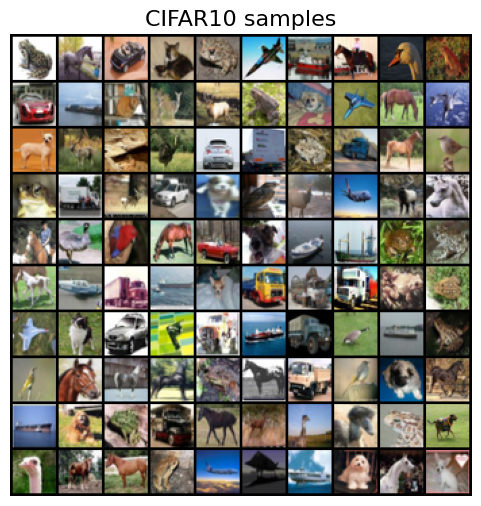

In [3]:
train_data, _, test_data, _ = load_dataset("cifar10", flatten=False, binarize=False)
visualize_images(train_data, "CIFAR10 samples")

### Problem 1: WGAN (3 pts)

[WGAN](https://arxiv.org/abs/1701.07875) model uses weight clipping to enforce Lipschitzness of the critic.

The model objective is
$$
\min_{G} W(\pi || p) \approx \min_{G} \max_{\boldsymbol{\phi} \in \boldsymbol{\Phi}} \left[ \mathbb{E}_{\pi(\mathbf{x})} f_{\boldsymbol{\phi}}(\mathbf{x})  - \mathbb{E}_{p(\mathbf{z})} f_{\boldsymbol{\phi}}(G_{\boldsymbol{\theta}}(\mathbf{z}))\right].
$$
Here $f_{\boldsymbol{\phi}}(\mathbf{x})$ is the critic model. The critic weights $\boldsymbol{\phi}$ should lie in the compact set $\boldsymbol{\Phi} = [-c, c]^d$.

In this task we will use convolutional networks for the generator $G_{\boldsymbol{\theta}}(\mathbf{z})$ and the critic $f_{\boldsymbol{\phi}}(\mathbf{x})$.

First of all, let define generator network. It will be the same for all WGAN models.

In [5]:
class GeneratorBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, upsample: bool = False) -> None:
        super().__init__()

        self.upsample = upsample
        if in_channels != out_channels:
            self.shortcut_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut_conv = None

        # ====
        # your code
        # define the layers
        
        # ====
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)

        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu2 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        # ====
        # your code
        # 1) create shortcut: if upsample is True, apply upsampling
        # 2) if shortcut_conv is not None, apply it
        # 3) apply main conv layers to x
        # NOTE: do not forget to add shortcut to x at the end
        
        # ====
        shortcut = x
        if self.upsample:
            shortcut = F.interpolate(shortcut, scale_factor=2, mode="nearest")
        if self.shortcut_conv is not None:
            shortcut = self.shortcut_conv(shortcut)

        x = self.bn1(x)
        x = self.relu1(x)
        if self.upsample:
            x = F.interpolate(x, scale_factor=2, mode="nearest")
        x = self.conv1(x)

        x = self.bn2(x)
        x = self.relu2(x)
        x = self.conv2(x)

        return x + shortcut

In [6]:
class ConvGenerator(nn.Module):
    def __init__(self, input_size: int = 128, n_channels: int = 64) -> None:
        super().__init__()
        self.n_channels = n_channels
        self.input_size = input_size
        # ====
        # your code
        # define the model as a sequence of layers
        # 1) start with Linear layer
        # 2) then define generator blocks
        # 3) create last conv layer with tanh activation
        #    we will center the data to [-1, 1]
        
        # ====
        self.linear = nn.Linear(input_size, 4 * 4 * 4 * n_channels)

        self.blocks = nn.Sequential(
            GeneratorBlock(4 * n_channels, 4 * n_channels, upsample=True),
            GeneratorBlock(4 * n_channels, 2 * n_channels, upsample=True),
            GeneratorBlock(2 * n_channels, n_channels, upsample=True),
        )

        self.output = nn.Sequential(
            nn.BatchNorm2d(n_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(n_channels, 3, kernel_size=3, stride=1, padding=1),
            nn.Tanh(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ====
        # your code
        # apply all layers
        
        # ====
        x = self.linear(x)
        x = x.view(x.shape[0], 4 * self.n_channels, 4, 4)
        x = self.blocks(x)
        output = self.output(x)
        return output
        
        
def test_conv_generator():
    model = ConvGenerator(input_size=4, n_channels=32)
    x = torch.randn((2, 4))
    out = model(x)
    assert list(out.size()) == [2, 3, 32, 32], out.size()
    
test_conv_generator()

Now it is time to define our critic. Here we will use the same class for all WGAN models, but the arguments will depend on the WGAN mode.

In [7]:
def avg_pool2d(x: torch.Tensor) -> torch.Tensor:
    return (x[:, :, ::2, ::2] + x[:, :, 1::2, ::2] + x[:, :, ::2, 1::2] + x[:, :, 1::2, 1::2]) / 4

class CriticBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, downsample=False, first=False):
        super().__init__()

        self.downsample = downsample
        self.first = first

        if in_channels != out_channels:
            self.shortcut_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut_conv = None
        # ====
        # your code
        # define the layers if block is first do not define ReLU
        # NOTE: do not use BatchNorm, because the gradient penalty (next task) 
        # should be independently imposed on different samples, 
        # but batch normalization brings batch correlation.
        
        # ====
        layers1 = []
        if not first:
            layers1.append(nn.ReLU(inplace=True))
        layers1.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1))
        self.block1 = nn.Sequential(*layers1)

        self.block2 = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ====
        # your code
        # 1) create shortcut: if downsample is True, apply avg_pool
        # 2) if shortcut_conv is not None, apply it
        # 3) apply main conv layers to x
        # NOTE: do not forget to add shortcut to x at the end
        
        # ====
        shortcut = x
        if self.downsample:
            shortcut = avg_pool2d(shortcut)
        if self.shortcut_conv is not None:
            shortcut = self.shortcut_conv(shortcut)

        x = self.block1(x)
        x = self.block2(x)
        if self.downsample:
            x = avg_pool2d(x)

        return x + shortcut

In [8]:
class ConvCritic(nn.Module):
    def __init__(
        self, n_channels: int, clip_c: Optional[float] = None,
    ) -> None:
        super().__init__()
        self.n_channels = n_channels
        self.clip_c = clip_c
        
        # ====
        # your code
        # define the model as a sequence of layers
        # 1) define generator blocks
        # 2) do not use sigmoid activation at the end!
        
        # ====
        self.blocks = nn.Sequential(
            CriticBlock(3, n_channels, downsample=True, first=True),
            CriticBlock(n_channels, 2 * n_channels, downsample=True),
            CriticBlock(2 * n_channels, 4 * n_channels, downsample=True),
            CriticBlock(4 * n_channels, 4 * n_channels, downsample=False),
        )

        self.relu = nn.ReLU(inplace=True)
        self.linear = nn.Linear(4 * n_channels, 1)

    def clip_weights(self) -> None:
        for module in self.modules():
            if isinstance(module, nn.Linear) or isinstance(module, nn.Conv2d):
                # ====
                # your code
                # clip the weight to the range [-clip_c, clip_c]
                # param.data.clamp_(-self.clip_c, self.clip_c)
                
                # ====
                module.weight.data.clamp_(-self.clip_c, self.clip_c)
                if module.bias is not None:
                    module.bias.data.clamp_(-self.clip_c, self.clip_c)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ====
        # your code
        # 1) clip the critic weights (if clip_c is given)
        # 2) apply all layers
        
        # ====
        if self.clip_c is not None:
            self.clip_weights()

        x = self.blocks(x)
        x = self.relu(x)
        x = x.sum(dim=(2, 3))
        output = self.linear(x)
        return output
        
        
def test_conv_critic():
    model = ConvCritic(n_channels=4, clip_c=0.01)
    x = torch.randn((2, 3, 32, 32))
    out = model(x)
    assert list(out.size()) == [2, 1], out.size()

    
test_conv_critic()

In [10]:
class WGAN(BaseModel):
    def __init__(
        self,
        input_size: int = 128, 
        n_channels: int = 64, 
        clip_c: Optional[float] = None,
    ) -> None:
        super().__init__()
        self.input_size = input_size
        self.generator = ConvGenerator(input_size, n_channels)
        self.discriminator = ConvCritic(n_channels, clip_c)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.generator(x)
    
    def loss(self):
        # keep it
        pass
    
    def loss_generator(self, batch_size) -> dict:
        # ====
        # your code
        # 1) sample batch 
        # NOTE: sample function uses torch.no_grad
        # 2) apply generator loss (only term with genrator)
        
        # ====
        z = torch.randn(batch_size, self.input_size, device=self.device)
        fake_data = self(z)
        g_loss = -self.discriminator(fake_data).mean()
        return {"generator_loss": g_loss}

    def loss_discriminator(self, x: torch.Tensor) -> dict:
        fake_data = self.sample(x.shape[0])
        fake_data = fake_data * 2 - 1
        # ====
        # your code
        # calculate critic loss (both terms)
        
        # ====
        d_loss_fake = self.discriminator(fake_data).mean()
        d_loss_real = -self.discriminator(x).mean()
        d_loss = d_loss_fake + d_loss_real
        return {"critic_loss": d_loss, "critic_loss_fake": d_loss_fake, "critic_loss_real": d_loss_real}
    
    @torch.no_grad()
    def sample(self, n_samples: int) -> torch.Tensor:
        # ====
        # your code
        # sample from standard normal distribution and apply the model
        
        # ====
        z = torch.randn(n_samples, self.input_size, device=self.device)
        output = self(z)
        return output * 0.5 + 0.5
    
def test_wgan():
    model = WGAN(input_size=4, n_channels=32)
    x = torch.randn((2, 4))
    out = model(x)
    assert list(out.size()) == [2, 3, 32, 32], out.size()
    
    out = model.sample(10)
    assert list(out.size()) == [10, 3, 32, 32], out.size()

    loss = model.loss_generator(10)
    assert isinstance(loss, dict)
    
    x = torch.randn((2, 3, 32, 32))
    loss = model.loss_discriminator(x)
    assert isinstance(loss, dict)
    
test_wgan()

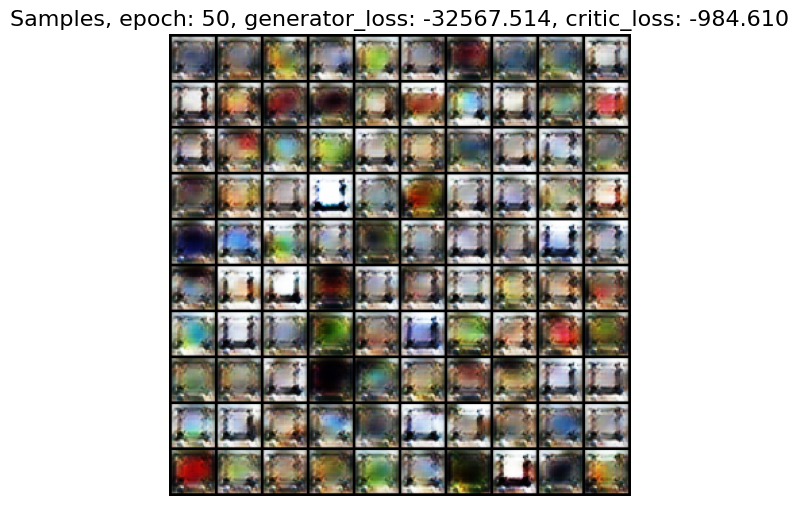

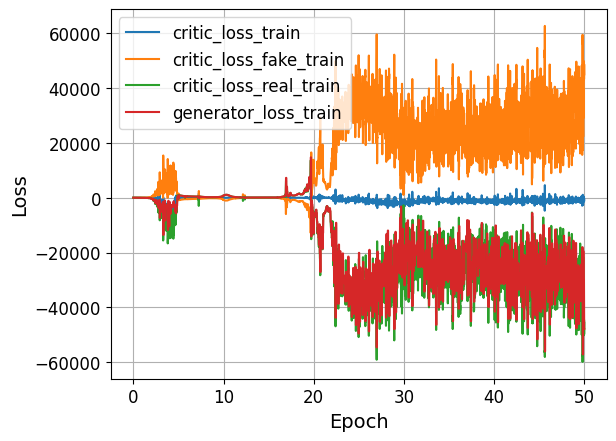

End of the training


In [11]:
# ====
# your code
# choose these parameters
BATCH_SIZE = 512
N_CHANNELS = 64
EPOCHS = 50
CRITIC_STEPS = 5 
CLIP_C = 0.01
LR = 5e-5
# ====

centered_train_data = train_data * 2 - 1
train_loader = data.DataLoader(centered_train_data, batch_size=BATCH_SIZE, shuffle=True)
wgan = WGAN(input_size=128, n_channels=N_CHANNELS, clip_c=CLIP_C)

# choose any optimizer as you want
generator_optimizer = torch.optim.RMSprop(wgan.generator.parameters(), lr=LR)
discriminator_optimizer = torch.optim.RMSprop(wgan.discriminator.parameters(), lr=LR)

train_adversarial(
    wgan,
    train_loader,
    epochs=EPOCHS,
    d_steps=CRITIC_STEPS,
    generator_optimizer=generator_optimizer,
    discriminator_optimizer=discriminator_optimizer,
    device=DEVICE,
    generator_loss_key="generator_loss",
    discriminator_loss_key="critic_loss",
    n_samples=100,
    visualize_samples=True
)

Let sample from our model and draw the samples.

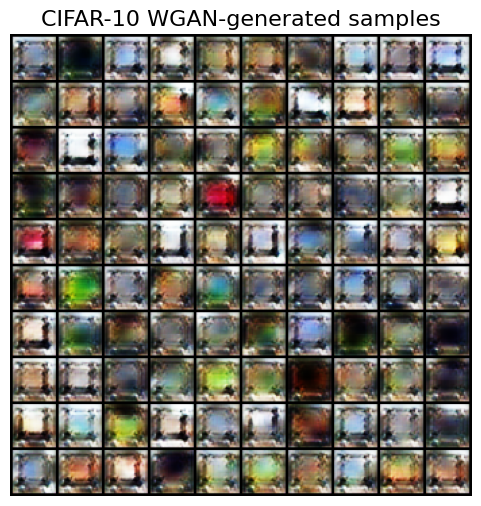

In [12]:
wgan.eval()
samples = wgan.sample(100).cpu().detach().numpy()

show_samples(samples, title="CIFAR-10 WGAN-generated samples")

### Problem 2: WGAN-GP for CIFAR 10 (2 pts)

Another way to enforce Lipschitzness comes from the following [theorem](https://arxiv.org/pdf/1704.00028.pdf):

Let $\pi(\mathbf{x})$ and $p(\mathbf{x})$ be two distribution in $\mathcal{X}$, a compact metric space. Let $\gamma$ be the optimal transportation plan between $\pi(\mathbf{x})$ and $p(\mathbf{x})$. Then, there is 1-Lipschitz function $f^*$ which is the optimal solution of 
$$
    \max_{\| f \|_L \leq 1} \left[ \mathbb{E}_{\pi(\mathbf{x})} f(\mathbf{x})  - \mathbb{E}_{p(\mathbf{x})} f(\mathbf{x})\right].
$$

if $f^*$ is differentiable, $\gamma(\mathbf{y} = \mathbf{z}) = 0$ and $\hat{\mathbf{x}}_t = t \mathbf{y} + (1 - t) \mathbf{z}$ with $\mathbf{y} \sim \pi(\mathbf{x})$, $\mathbf{z} \sim p(\mathbf{x} | \mathbf{\theta})$, $t \in [0, 1]$ it holds that
$$
    \mathbb{P}_{(\mathbf{y}, \mathbf{z}) \sim \gamma} \left[ \nabla f^*(\hat{\mathbf{x}}_t) = \frac{\mathbf{z} - \hat{\mathbf{x}}_t}{\| \mathbf{z} - \hat{\mathbf{x}}_t \|} \right] = 1.
$$

This follows that $f^*$ has gradient norm 1 almost everywhere under $\pi(\mathbf{x})$ and $p(\mathbf{x})$. Thus, we can add a term that will enforce the gradient to equal 1:
$$
 W(\pi || p) = \underbrace{\mathbb{E}_{\pi(\mathbf{x})} f(\mathbf{x})  - \mathbb{E}_{p(\mathbf{x} | \boldsymbol{\theta})} f(\mathbf{x})}_{\text{original critic loss}} + \lambda \underbrace{\mathbb{E}_{U[0, 1]} \left[ \left( \| \nabla_{\hat{\mathbf{x}}} f(\hat{\mathbf{x}}) \|_2 - 1 \right) ^ 2\right]}_{\text{gradient penalty}},
$$
where $t \sim U[0,1]$ is uniformly distributed.

Let define our gradient penalty loss.

In [13]:
class WGAN_GP(WGAN):
    def __init__(
        self,
        gp_weight: float,
        input_size: int = 128, 
        n_channels: int = 64, 
    ) -> None:
        super().__init__()
        self.input_size = input_size
        self.gp_weight = gp_weight
        self.generator = ConvGenerator(input_size, n_channels)
        self.discriminator = ConvCritic(n_channels, None)

    def gradient_penalty(
        self, real_data: torch.Tensor, fake_data: torch.Tensor
    ) -> torch.Tensor:
        batch_size = real_data.shape[0]

        # ====
        # your code
        # Calculate interpolation x_t = t * x_real + (1 - t) x_fake
        # 1) sample t
        # 2) create x_t (be careful about shapes)
        # 3) apply critic to x_t
        
        # ====
        t = torch.rand(batch_size, 1, 1, 1, device=real_data.device)
        x_t = t * real_data + (1 - t) * fake_data
        x_t.requires_grad_(True)
        d_output = self.discriminator(x_t)
        gradients = torch.autograd.grad(
            outputs=d_output,
            inputs=x_t,
            grad_outputs=torch.ones(d_output.size()).to(fake_data.device),
            create_graph=True,
            retain_graph=True,
        )[0]

        gradients = gradients.reshape(batch_size, -1)
        # ====
        # your code
        # compute gradient norm
        
        # ====
        gradients_norm = gradients.norm(2, dim=1)
        return ((gradients_norm - 1) ** 2).mean()
    
    def loss_discriminator(self, x: torch.Tensor) -> dict:
        fake_data = self.sample(x.shape[0])
        fake_data = fake_data * 2 - 1
        # ====
        # your code
        # calculate critic loss (both terms)
        
        # ====
        d_loss_fake = self.discriminator(fake_data).mean()
        d_loss_real = -self.discriminator(x).mean()
        gp = self.gradient_penalty(x, fake_data)
        d_loss = d_loss_fake + d_loss_real + self.gp_weight * gp
        losses = {
            "critic_loss": d_loss, 
            "critic_loss_fake": d_loss_fake, 
            "critic_loss_real": d_loss_real,
            "gradient_penalty_loss": gp
        }
        return losses

That is all :)

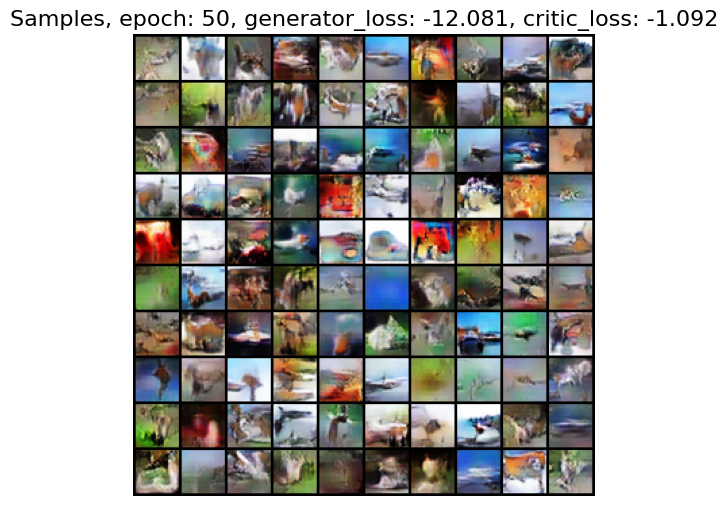

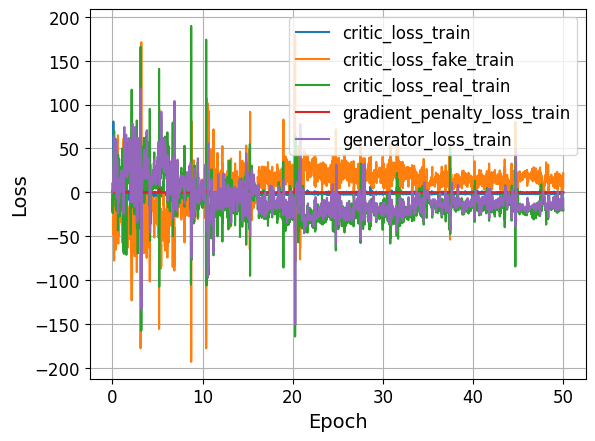

End of the training


In [14]:
# ====
# your code
# choose these parameters
BATCH_SIZE = 512
N_CHANNELS = 64
EPOCHS = 50
CRITIC_STEPS = 5
GP_WEIGHT = 10.0
LR = 3e-4
# ====

centered_train_data = train_data * 2 - 1
train_loader = data.DataLoader(centered_train_data, batch_size=BATCH_SIZE, shuffle=True)
wgan_gp = WGAN_GP(gp_weight=GP_WEIGHT, input_size=128, n_channels=N_CHANNELS)


# choose any optimizer as you want
generator_optimizer = torch.optim.Adam(wgan_gp.generator.parameters(), lr=LR, betas=(0.0, 0.99))
discriminator_optimizer = torch.optim.Adam(wgan_gp.discriminator.parameters(), lr=LR, betas=(0.0, 0.99))

train_adversarial(
    wgan_gp,
    train_loader,
    epochs=EPOCHS,
    d_steps=CRITIC_STEPS,
    generator_optimizer=generator_optimizer,
    discriminator_optimizer=discriminator_optimizer,
    device=DEVICE,
    generator_loss_key="generator_loss",
    discriminator_loss_key="critic_loss",
    n_samples=100,
    visualize_samples=True
)

Let sample from our model and draw the samples.

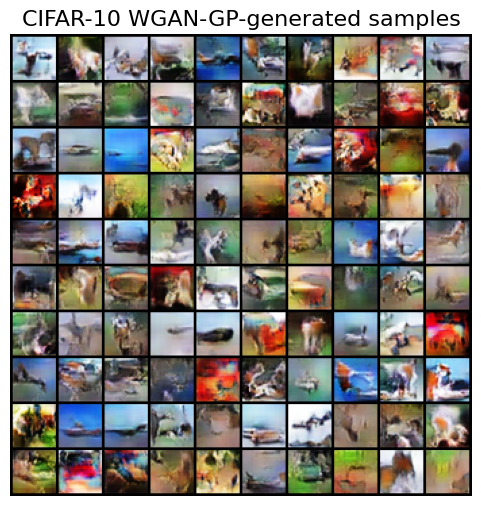

In [15]:
wgan_gp.eval()
samples = wgan_gp.sample(100).cpu().detach().numpy()

show_samples(samples, title="CIFAR-10 WGAN-GP-generated samples")

Here you have to get samples with good enough quality!

## Task 3: Noise Conditioned Score Network for CIFAR 10 (5 pts)

Now we try to extend our model to the NCSN. It means that we have to add multiple noise scales.

We will use UNet - a standart choice for all family of diffusion models. We'll begin with a simple implementation (`nn.GroupNorm` and `nn.Embedding`) and progressively enhance it with advanced components in future homeworks.

First, we'll define the UNet's core component. It is the `ResBlock`, which enhances standard ResNet blocks with timestep embeddings.

In [4]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, t_dim, dropout):
        super().__init__()
             
        self.temb_proj = nn.Sequential(nn.SiLU(), nn.Linear(t_dim, out_channels))

        # ====
        # your code
        # create two convolutional blocks of nn.Sequential
        # first block should take raw input
        # second block should take the output of the first block with added time and class embeddings
        # it is preferrable to use nn.GroupNorm (~8 groups), nn.SiLU and nn.Dropout
        
        # ====
        self.block1 = nn.Sequential(
            nn.GroupNorm(8, in_channels),
            nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
        )

        self.block2 = nn.Sequential(
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
        )

        self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()
    
    def forward(self, x, temb):
        # ====
        # your code
        # 1) pass x through the first block
        # 2) add time embedding (unsqueeze it to the right shape)
        # 3) pass the result through the second block
        # 4) add the shortcut
        
        # ====
        h = self.block1(x)
        h = h + self.temb_proj(temb)[:, :, None, None]
        h = self.block2(h)
        h = h + self.shortcut(x)
        return h

The `DownsampleBlock` and `UpsampleBlock` implement the UNet's characteristic encoder-decoder structure, managing resolution changes as features flow through the network.

In [5]:
class DownsampleBlock(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        # ====
        # your code 
        # define convolutional layer that:
        # 1) does not change the number of channels
        # 2) reduces the size of the image twice
        
        # ====
        self.conv = nn.Conv2d(channels, channels, kernel_size=3, stride=2, padding=1)

    def forward(self, input_tensor: torch.Tensor, *args) -> torch.Tensor:
        # ====
        # your code
        
        # ====
        x = self.conv(input_tensor)
        return x

class UpsampleBlock(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        # ====
        # your code 
        # define convolutional layer that:
        # 1) does not change the number of channels
        # 2) does not reduce the size of the image
        
        # ====
        self.conv = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1)

    def forward(self, input_tensor: torch.Tensor, *args) -> torch.Tensor:
        # ====
        # your code
        # 1) upsample the input tensor using bilinear interpolation
        # 2) pass the result through the convolutional layer
        
        # ====
        x = F.interpolate(input_tensor, scale_factor=2, mode="bilinear", align_corners=False)
        x = self.conv(x)
        return x

Finally, we define the complete `UNet` - the neural network backbone of our diffusion model that handles both encoding and decoding with skip connections. Look at the code carefully.

In [6]:
class UNet(nn.Module):
    def __init__(
        self, 
        num_timesteps: int, 
        hidden_channels: int, 
        channel_multipliers: List[int], 
        in_channels: int = 3,
        num_blocks: int = 1,
        dropout: float = 0.1
    ):
        super().__init__()
        
        temb_dim = hidden_channels * 4
        self.time_embedding = nn.Embedding(num_timesteps, temb_dim)
        self.head = nn.Conv2d(in_channels, hidden_channels, kernel_size=3, stride=1, padding=1)
        channel_list, curr_channels = [hidden_channels], hidden_channels

        # initialization of downsample blocks
        self.downsample_blocks = nn.ModuleList()
        for idx, scale in enumerate(channel_multipliers):
            out_channels = hidden_channels * scale
            is_last = (idx == len(channel_multipliers) - 1)

            # make multiple ResBlocks at each scale
            for _ in range(num_blocks):
                # at each channel_multipliers scale we add ResBlock
                # last block has attention
                self.downsample_blocks.append(
                    ResBlock(curr_channels, out_channels, temb_dim, dropout)
                )
                curr_channels = out_channels
                channel_list.append(curr_channels)

            # add downsample block if not last block
            if not is_last:
                self.downsample_blocks.append(DownsampleBlock(curr_channels))
                channel_list.append(curr_channels)
        
        # initialization of bottleneck block
        self.bottleneck = nn.ModuleList([
            ResBlock(curr_channels, curr_channels, temb_dim, dropout),
            ResBlock(curr_channels, curr_channels, temb_dim, dropout)
        ])
        
        # initialization of upsample blocks
        self.upsample_blocks = nn.ModuleList()
        for idx, scale in reversed(list(enumerate(channel_multipliers))):
            out_channels = hidden_channels * scale
            is_first, is_last = (idx == 0), (idx == len(channel_multipliers) - 1)

            # make multiple ResBlocks at each scale
            for _ in range(num_blocks + 1):
                # at each reverse channel_multipliers scale we add ResBlock
                # first block has attention
                self.upsample_blocks.append(
                    ResBlock(channel_list.pop() + curr_channels, out_channels, temb_dim, dropout)
                )
            
                curr_channels = out_channels
            
            # add upsample block if not last block
            if not is_first:
                self.upsample_blocks.append(UpsampleBlock(curr_channels))
                
        self.tail = nn.Sequential(
            nn.GroupNorm(8, curr_channels),
            nn.SiLU(),
            nn.Conv2d(curr_channels, in_channels, kernel_size=3, stride=1, padding=1)
        )

    def forward(self, x, t):
        temb = self.time_embedding(t)

        h = self.head(x)
        skip_connections = [h] # save intermediate results for skip connections

        # downsample
        for layer in self.downsample_blocks:
            h = layer(h, temb)
            skip_connections.append(h) # save intermediate results for skip connections

        # bottleneck
        for layer in self.bottleneck:
            h = layer(h, temb)
        
        # upsample
        for layer in self.upsample_blocks:
            if isinstance(layer, ResBlock): # apply skip connection
                skip_connection = skip_connections.pop()
                h = torch.cat([h, skip_connection], dim=1)
            h = layer(h, temb)

        h = self.tail(h)
        return h

def test_unet():
    model = UNet(
        num_timesteps=10, 
        hidden_channels=128, 
        channel_multipliers=[1, 2, 4],
        num_blocks=2 
    )
    x = torch.rand((2, 3, 32, 32))
    t = torch.zeros(size=(2,), dtype=torch.long)
    out1 = model(x, t)
    t = torch.ones(size=(2,), dtype=torch.long)
    out2 = model(x, t)
    assert not np.allclose(out1.detach().numpy(), out2.detach().numpy())


test_unet()

Now lets define the main model.

We will use the sequence of the noise levels: $\sigma_1 < \sigma_2 < \dots < \sigma_T$. In this task it will be the geometric progression.
And we will perturb the original data with the different noise levels to obtain 
$$
\mathbf{x}_t = \mathbf{x} + \sigma_t \cdot \boldsymbol{\epsilon}, \quad \mathbf{x}_t \sim q(\mathbf{x}_t). 
$$

Our training objective:
$$
    \sum_{t=1}^T \frac{\sigma_t^2}{\sigma_T^2} \mathbb{E}_{\pi(\mathbf{x})} \mathbb{E}_{q(\mathbf{x}_t | \mathbf{x})}\bigl\| \mathbf{s}_{\boldsymbol{\theta}, \sigma_t}(\mathbf{x}_t) - \nabla_{\mathbf{x}_{\sigma}} \log q(\mathbf{x}_t | \mathbf{x}) \bigr\|^2_2 \rightarrow \min_{\boldsymbol{\theta}}
$$
But instead of doing the honest summation we will sample one timestamp for each sample.

We will use annealed Langevin dynamics to sample from our model:
1. Sample $\mathbf{x}_0 \sim \mathcal{N}(0, \sigma_T^2 \cdot \mathbf{I}) \approx q(\mathbf{x}_T)$.
2. Apply $L$ steps of Langevin dynamic
$$
    \mathbf{x}_l = \mathbf{x}_{l-1} + \frac{\eta_t}{2} \cdot \mathbf{s}_{\boldsymbol{\theta}, \sigma_t}(\mathbf{x}_{l - 1}) + \sqrt{\eta_t} \cdot \boldsymbol{\epsilon}_l.
$$
3. Update $\mathbf{x}_0 := \mathbf{x}_L$ and choose the next $\sigma_t$.
4. Repeat it for all sigmas.

**Note:** use the following formula for $\eta_t = \epsilon \cdot \frac{\sigma_t^2}{\sigma_T^2}$ ($\epsilon$ is a small number that is a hyperparameter of the sampling).

In [7]:
class NoiseConditionedScoreNetwork(BaseModel):
    def __init__(self, input_shape: Tuple[int, int], sigmas: List[float], hidden_channels: int, channel_multipliers: List[int], num_blocks: int):
        super().__init__()

        self.score_model = UNet(
            num_timesteps=len(sigmas), hidden_channels=hidden_channels, channel_multipliers=channel_multipliers, num_blocks=num_blocks, in_channels=input_shape[0]
        )
        self.input_shape = input_shape
        self.sigmas = torch.FloatTensor(sorted(sigmas, reverse=True))

    def forward(self, x: torch.Tensor):
        self.sigmas = self.sigmas.to(self.device)
        batch_size = x.shape[0]
        # ====
        # your code
        # sample gaussian noise
        # sample timestamps for each datapoint in the batch
        # choose sigmas for these datapoints
        # add noises to the x samples

        # =====
        which_sigmas = torch.randint(0, len(self.sigmas), (batch_size,), device=self.device)
        used_sigmas = self.sigmas[which_sigmas].view(batch_size, 1, 1, 1)
        noise = torch.randn_like(x) * used_sigmas
        noisy_x = x + noise

        # calculate the score model
        s = self.score_model(noisy_x, which_sigmas)

        # ====
        # your code
        # compute the loss
        # it is mse between score function and gradient of the normal distribution (do not forget the coefficient before the mse)

        # =====
        target = -noise / (used_sigmas**2)
        loss = 0.5 * (used_sigmas**2) * (s - target) ** 2
        return loss

    def loss(self, x: torch.Tensor):
        return {"total_loss": self(x).mean(dim=0).sum()}

    def annealed_langevin_dynamics(self, x: torch.Tensor, num_steps: int, eps: float):
        # =====
        # your code
        # here we will have 2 cycles: one for sigmas, one for Langevin sampling
        # start with the largest sigma, apply Langevin dynamic for it and move to the next sigma

        # =====
        self.sigmas = self.sigmas.to(self.device)
        sigma_min = self.sigmas[-1]

        for idx, sigma in enumerate(self.sigmas):
            step_size = eps * (sigma / sigma_min) ** 2
            t = torch.full((x.shape[0],), idx, device=self.device, dtype=torch.long)

            for _ in range(num_steps):
                noise = torch.randn_like(x)
                score = self.score_model(x, t)
                x = x + 0.5 * step_size * score + torch.sqrt(step_size) * noise
                return x

    @torch.no_grad()
    def sample(self, num_samples: int = 64, num_steps: int = 10, eps: float = 0.1):
        # we sample x_0 from U[-1, 1]
        x0 = 2.0 * torch.rand_like(torch.empty(num_samples, *self.input_shape)) - 1.0
        x0 = x0.to(self.device)

        # run langevine dynamics
        x = self.annealed_langevin_dynamics(x0, num_steps=num_steps, eps=eps)
        return (x.clip(-1.0, 1) + 1) / 2


def test_ncsn():
    ncsn = NoiseConditionedScoreNetwork(input_shape=(1, 8, 8), sigmas=[0.1], hidden_channels=64, channel_multipliers=[1, 2], num_blocks=1)
    x = torch.rand((2, 1, 8, 8))
    assert x.size() == ncsn(x).size()
    loss = ncsn.loss(x)["total_loss"]
    assert len(loss.size()) == 0
    assert list(ncsn.sample(4).size()) == [4, 1, 8, 8]


test_ncsn()

In [8]:
# ====
# your code
# choose these parameters
BATCH_SIZE = 256
LR = 3e-4
EPOCHS = 10
HIDDEN_CHANNELS = 64
CHANNEL_MULTIPLIERS = [1, 2, 2]
NUM_BLOCKS = 2
# ====

sigma_max = 1.
sigma_min = 0.01
L = 10
SIGMAS = [
    sigma_max * (sigma_min/sigma_max)**((i)/(L-1)) for i in range(L)
]


centered_train_data = train_data * 2 - 1
centered_test_data = test_data * 2 - 1
train_loader = data.DataLoader(centered_train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = data.DataLoader(centered_test_data, batch_size=BATCH_SIZE, shuffle=False)

ncsn = NoiseConditionedScoreNetwork(
    input_shape=(3, 32, 32), sigmas=SIGMAS, 
    hidden_channels=HIDDEN_CHANNELS, 
    channel_multipliers=CHANNEL_MULTIPLIERS,
    num_blocks=NUM_BLOCKS
)

# choose any optimizer/scheduler as you want
optimizer = torch.optim.AdamW(ncsn.parameters(), lr=LR, betas=(0.9, 0.999), weight_decay=1e-3)

# train
train_model(
    ncsn,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    optimizer=optimizer,
    device=DEVICE,
    n_samples=16,
    visualize_samples=False, # probably you don't want to visualize samples, since it takes a lot of time
)

Start of the training


Evaluating epoch 0:   0%|          | 0/40 [00:00<?, ?it/s]

Training epoch 1:   0%|          | 0/196 [00:00<?, ?it/s]

KeyboardInterrupt: 

Now you can try to select proper inference parameters to obtain better images.

Unfortunately, inference with this class of models is computationally intensive and slow. Generating 100 images requires approximately 5 minutes on a GTX 1080 Ti GPU :(

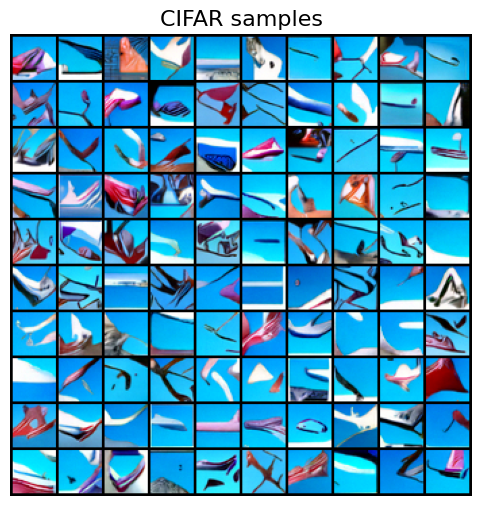

In [ ]:
# ====
# your code
# choose these parameters
NUM_STEPS = 16
EPS = 1e-5
# ====

samples = ncsn.sample(100, num_steps=NUM_STEPS, eps=EPS).cpu()
show_samples(samples, "CIFAR samples")